# Ultimate Data Science Challenge

This notebook contains all three parts of the take-home challenge:
1. Exploratory data analysis
2. Experiment and metrics design
3. Predictive modeling

In [1]:
# Imports and global setup
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

## Part 1 - Exploratory Data Analysis (logins.json)
Aggregate login counts to 15-minute intervals, visualize the time series, and report key demand patterns and data quality observations.

In [2]:
# Load login data
data_dir = Path('../data/raw')
logins_path = data_dir / 'logins.json'

with open(logins_path, 'r') as f:
    raw_logins = json.load(f)

logins = pd.DataFrame(raw_logins)


In [3]:
print(logins.head())
print(logins.tail())
print(f'Shape: {logins.shape}')
print('Info:')
logins.info()

            login_time
0  1970-01-01 20:13:18
1  1970-01-01 20:16:10
2  1970-01-01 20:16:37
3  1970-01-01 20:16:36
4  1970-01-01 20:26:21
                login_time
93137  1970-04-13 18:50:19
93138  1970-04-13 18:43:56
93139  1970-04-13 18:54:02
93140  1970-04-13 18:57:38
93141  1970-04-13 18:54:23
Shape: (93142, 1)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   login_time  93142 non-null  object
dtypes: object(1)
memory usage: 727.8+ KB


In [4]:
# Parse timestamps
logins['login_time'] = pd.to_datetime(logins['login_time'], errors='coerce')

quality_summary = {
    'rows': len(logins),
    'null_login_time': int(logins['login_time'].isna().sum()),
    'duplicate_rows': int(logins.duplicated().sum())
}
quality_summary

{'rows': 93142, 'null_login_time': 0, 'duplicate_rows': 877}

In [ ]:
retention_rate = users['retained'].mean()
print(f'retention_rate: {retention_rate:.2%}')

retention_rate: 37.61%


In [5]:
# Check the first few rows of the logins DataFrame after parsing timestamps
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [6]:
# Check date range
print(f"Date range: {logins['login_time'].min()} to {logins['login_time'].max()}")

Date range: 1970-01-01 20:12:16 to 1970-04-13 18:57:38


In [7]:
#  Aggregate to 15-minute bins

login_counts_15m = (
    logins.dropna(subset=['login_time'])
    .set_index('login_time')
    .resample('15min')
    .size()
    .rename('login_count')
    .to_frame()
)

In [8]:
# Check the first few rows of the aggregated login counts
login_counts_15m.head()

,login_count
login_time,
1970-01-01 20:00:00,2
1970-01-01 20:15:00,6
1970-01-01 20:30:00,9
1970-01-01 20:45:00,7
1970-01-01 21:00:00,1


In [9]:
# Check temporal continuity
time_range = login_counts_15m.index.max() - login_counts_15m.index.min()
expected_bins = int(time_range.total_seconds() / (15 * 60)) + 1
actual_bins = len(login_counts_15m)
print(f'Expected bins: {expected_bins}, Actual bins: {actual_bins}')

Expected bins: 9788, Actual bins: 9788


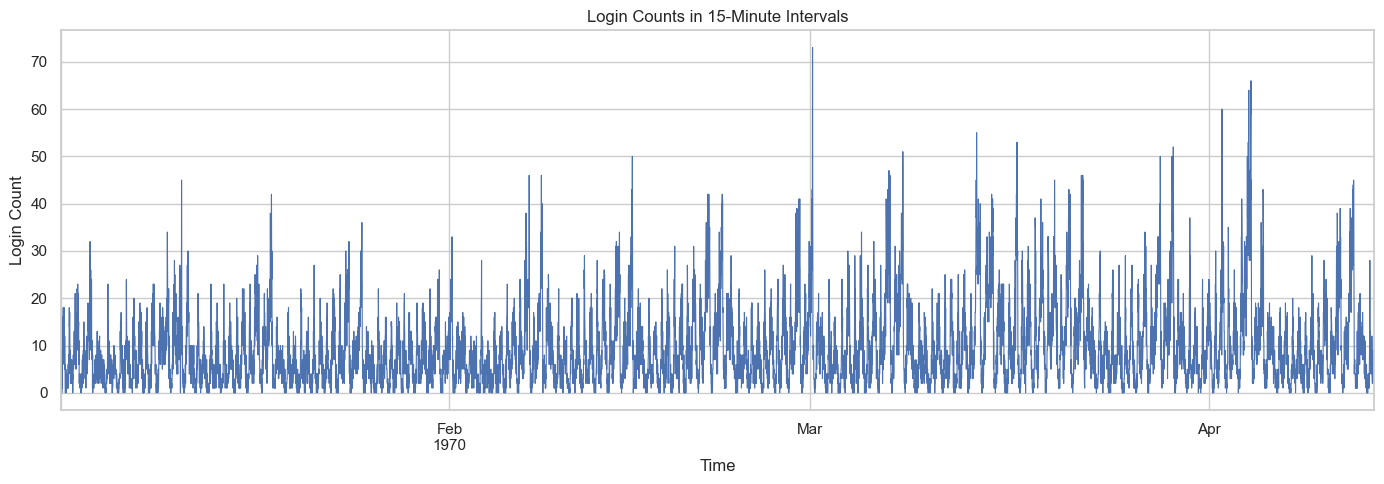

In [10]:
# Time series visualization
fig, ax = plt.subplots(figsize=(14, 5))
login_counts_15m['login_count'].plot(ax=ax, linewidth=0.8)
ax.set_title('Login Counts in 15-Minute Intervals')
ax.set_xlabel('Time')
ax.set_ylabel('Login Count')
plt.tight_layout()
plt.show()

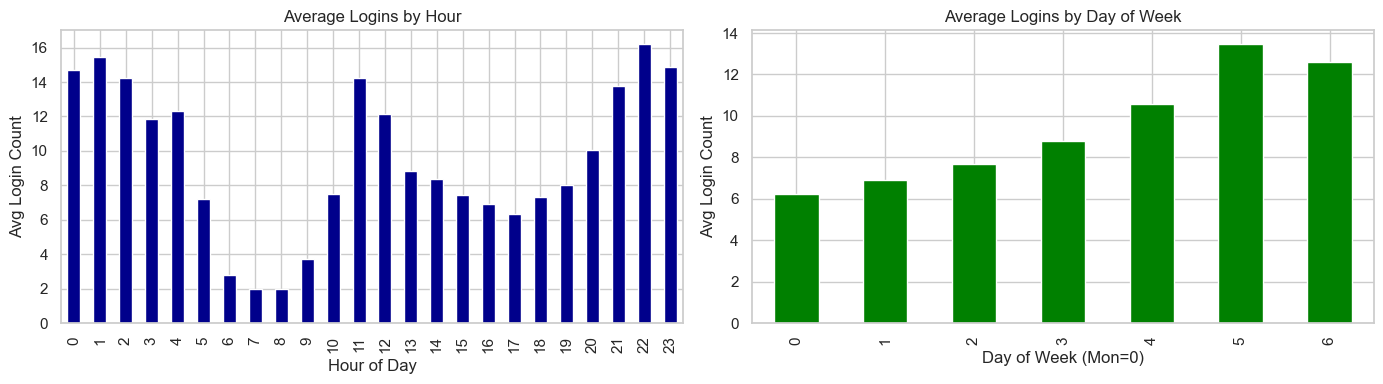

In [11]:
# Daily and weekly demand pattern views
tmp = login_counts_15m.copy()
tmp['hour'] = tmp.index.hour
tmp['dayofweek'] = tmp.index.dayofweek  # Monday=0, Sunday=6

hourly_profile = tmp.groupby('hour')['login_count'].mean()
dow_profile = tmp.groupby('dayofweek')['login_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_profile.plot(kind='bar', ax=axes[0], color='darkblue')
axes[0].set_title('Average Logins by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Login Count')

dow_profile.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Average Logins by Day of Week')
axes[1].set_xlabel('Day of Week (Mon=0)')
axes[1].set_ylabel('Avg Login Count')

plt.tight_layout()
plt.show()

In [12]:
hourly_profile.sort_values(ascending=False)

hour
22    16.193627
1     15.482843
23    14.848039
0     14.688725
2     14.215686
11    14.213235
21    13.781863
4     12.338235
12    12.166667
3     11.840686
20    10.056373
13     8.850490
14     8.397059
19     8.007426
10     7.509804
15     7.446078
18     7.303922
5      7.218137
16     6.941176
17     6.333333
9      3.742647
6      2.789216
8      2.004902
7      1.997549
Name: login_count, dtype: float64

In [13]:
dow_profile.sort_values(ascending=False)

dayofweek
5    13.456250
6    12.615972
4    10.561111
3     8.794118
2     7.692708
1     6.895833
0     6.213380
Name: login_count, dtype: float64

### Part 1 Write-up

#### Data Quality

- No missing or unparseable timestamps were detected, and the time series contains no gaps — the number of 15-minute bins matched the expected count across the full date range. No duplicate rows were found. The dataset appears clean and complete.

#### Demand Features

- Daily cycle: Login demand follows a bimodal pattern. Activity drops to a morning low around 7 am (≈2.0 avg logins per 15-min bin), rises to a midday peak around 11 am (≈14.2), dips again in the late afternoon around 5 pm (≈6.3), then climbs to an evening peak around 10 pm (≈16.2) — the busiest period of the day.

- Weekly cycle: Monday is the quietest day (≈6.2 avg logins per bin). Demand rises steadily through the week, peaking on Saturday (≈13.5) and remaining elevated on Sunday (≈12.6), suggesting substantially higher weekend engagement.

#### Business implications--supply & demand

**Daily cycle**

- Driver-partner supply: Schedule driver-partner incentives and/or surge pricing before peak times to ensure adequate supply during peak demand.

- Late-night demand: The high evening peak suggests a nightlife/social use case so targeting marketing or promotions toward evening riders could have significant returns.

- Morning and afternoon lulls: The absence of morning and evening morning and afternoon commute peaks are counterintuitive given typical commuter hours and warrant further investigation. It may represent an opportunity to grow market proportion among commuters.   

**Weekly Cycle**

- Weekend supply: Driver-partners need incentives to be available Friday-Sundary when demand is highest.

- Weekday demand: Low weekday demand presents an opportunity to run targeted campains to promote mid-week usage.

**Retention**

- Building weekday use cases, such as commuting, could make the app feel more integral to day-to-day life and improve retention.

**Cross-cutting (combining daily and weekly cycles)**

- The highest-risk supply gap is Friday, Saturday, and Sunday evenings--the combination of peak days with peak hours. Any capacity or pricing strategy should take both hour-of-day and day-of-week into account.

**Limitations**

- Logins are a proxy for demand, not confirmed ride requests or completions. Conversion rate from login to completed ride is unknown, so the demand may be different that it appears.

- The date range is limited as it only includes January 1, 1970 through April 13, 1970. Therefore, we can't evaluate whether the patterns change seasonally or are stable throughout the year.

- The geographic context is unknown and local factors could help exlain certain patterns, such as the missing commute peaks.

- The presence or role of competitors is unknown.

- The chosen aggregation levels, 15-minute, hourly, and weekly may not capture all important patterns.

## Part 2 - Experiment and Metrics Design
Propose a key success metric and a practical experiment to evaluate toll reimbursement impact on cross-city driver behavior.

### 2.1 Key Metric

Our primary metric will be the proportion of driver-partners who completed at least one pickup in each city within a given week. A driver chooses where to be available and accept rides, whereas drop-off location is determined by the rider. Pickup location, therefore, is more likely to reflect a deliberate decision by the driver to position in a particular city

### 2.2 Experiment Design
- Population and randomization unit
- Treatment and control definitions
- Experiment duration and power considerations
- Guardrail metrics (earnings, wait time, rider cancellations, etc.)

#### Population and Randomization Unit

- Randomization unit: individual driver-partner.
- Baseline window for assignment: 4 weeks immediately before experiment launch.

#### Eligibility Criteria

- Include driver-partners who are currently active and completed at least N trips during the baseline window.
- Assign each eligible driver-partner to a baseline city using majority pickup proportion:
  - Gotham if pickup proportion in Gotham > X%.
  - Metropolis otherwise.
- Exclude drivers with very low activity (fewer than N trips) because city assignment is unstable.
- Optionally exclude near-50/50 drivers (for example, 45%-55% pickup split) and analyze them separately as already multi-city.

#### Treatment and Control

- Treatment group: receives full toll reimbursement for all eligible bridge crossings during the experiment.
- Control group: no reimbursement (business-as-usual policy).
- Assignment: stratified randomization by baseline city (and optionally by baseline trip volume tier) to keep treatment and control balanced.

#### Experiment Duration and Detectability

- Evaluation window: 4 weeks after treatment launch.
- Run a pre-experiment power analysis to choose sample size and treatment proportion.
- Inputs for power analysis:
  - Baseline dual-city participation rate.
  - Minimum detectable effect (MDE) that is operationally meaningful.
  - Significance level alpha = 0.05 and target power = 0.80.
- If reimbursement budget is unconstrained, use a 50/50 split for maximum statistical efficiency; otherwise use a smaller treatment proportion and increase duration/sample size as needed.

#### Guardrail Metrics

- Average driver earnings per hour.
- Rider wait time / pickup ETA.
- Cancellation rates (rider and driver).
- Trip completion rate.
- Net incentive cost per incremental dual-city driver-partner.

### 2.3 Statistical Test and Interpretation

#### Primary Test: Two-Proportion Z-Test

Compare the proportion of driver-partners who achieved at least one pickup in each city per week between treatment and control groups.

- **Null hypothesis (H₀):** The proportion of dual-city driver-partners is the same in the treatment and control groups.
- **Alternative hypothesis (H₁):** The proportion is higher in the treatment group.
- **Significance level:** α = 0.05 (one-tailed, since we hypothesize a positive direction).
- **Target power:** 0.80.
- **Confidence interval:** Report a 95% CI on the difference in proportions to communicate practical magnitude, not just statistical significance.

Assumptions:
- Observations are independent (individual-level randomization satisfies this).
- Sample sizes are large enough for the normal approximation (verified via the power analysis in Section 2.2).
- No interference between treatment and control (drivers in the control group are not materially affected by reimbursements drivers in the treatment group).

#### Secondary Analysis: Logistic Regression (Robustness Check)

If imbalances exist between groups after randomization, use logistic regression to confirm the treatment effect holds after adjusting for confounders:

- **Outcome:** Binary — 1 if the driver achieved dual-city pickups in a given week, 0 otherwise.
- **Key predictor:** Treatment assignment (1 = reimbursed, 0 = control).
- **Covariates:** Baseline city, baseline trip volume tier, driver tenure, and day-of-week/time-of-day activity patterns.
- Report the odds ratio and 95% CI for the treatment coefficient as the primary effect estimate.

#### Interpreting Outcomes

| Result | Interpretation | Recommendation |
|--------|---------------|----------------|
| Significant increase in dual-city participation; guardrail metrics stable | Toll reimbursement is effective with no marketplace harm | Roll out to all eligible driver-partners |
| Significant increase; guardrail metrics degrade | Effective but costly or disruptive | Investigate mechanism; explore partial reimbursement or redesigned incentive structure |
| No significant increase | Toll cost is not the primary barrier to dual-city driving | Investigate other barriers (time, unfamiliarity, routing) before further investment |
| Significant decrease | Reimbursement had unintended negative consequences | Do not roll out; investigate mechanism |

#### Caveats

- **Novelty effect:** Driver-partners may explore dual-city operation briefly because the incentive is new and then revert. A follow-up measurement could test whether behavior change is sustained.
- **Interference:** If treatment drivers migrate to Metropolis and displace control drivers, the control group's activity may be suppressed, biasing the estimated treatment effect upward.
- **Generalizability:** 
    - Findings apply to the current driver-partner population and the specific toll cost level tested. A change in toll pricing would require a new experiment.
    - Results from a 4-week window may not generalize to other times of year, events, or holidays.

## Part 3 - Predictive Modeling
Build and evaluate a model to predict whether a user is active in month 6.

In [14]:
# Load ultimate_data_challenge.json dataset
users_path = data_dir / 'ultimate_data_challenge.json'
users = pd.read_json(users_path)
users.head(), users.shape

(             city  trips_in_first_30_days signup_date  avg_rating_of_driver  \
 0  King's Landing                       4  2014-01-25                   4.7   
 1         Astapor                       0  2014-01-29                   5.0   
 2         Astapor                       3  2014-01-06                   4.3   
 3  King's Landing                       9  2014-01-10                   4.6   
 4      Winterfell                      14  2014-01-27                   4.4   
 
    avg_surge last_trip_date    phone  surge_pct  ultimate_black_user  \
 0       1.10     2014-06-17   iPhone       15.4                 True   
 1       1.00     2014-05-05  Android        0.0                False   
 2       1.00     2014-01-07   iPhone        0.0                False   
 3       1.14     2014-06-29   iPhone       20.0                 True   
 4       1.19     2014-03-15  Android       11.8                False   
 
    weekday_pct  avg_dist  avg_rating_by_driver  
 0         46.2      3.67   

In [15]:
# Basic cleaning and target construction
users['last_trip_date'] = pd.to_datetime(users['last_trip_date'], errors='coerce')
users['signup_date'] = pd.to_datetime(users['signup_date'], errors='coerce')

snapshot_date = users['last_trip_date'].max()
users['retained'] = (users['last_trip_date'] >= (snapshot_date - pd.Timedelta(days=30))).astype(int)


The data cleaning step is minimal and focused on making the retention label reliable. last_trip_date and signup_date are converted to datetime so time-based comparisons work correctly, and the analysis uses the most recent observed last_trip_date in the dataset as the reference snapshot.

The target is then constructed as a binary retention indicator: a user is labeled retained if their last trip occurred within 30 days of that snapshot date, and not retained otherwise. This approach creates a clear supervised learning target for the modeling step.

In [16]:
retention_rate = users['retained'].mean()
print(f'retention_rate: {retention_rate:.2%}')

retention_rate: 37.61%


In [17]:
# Define categorical and numeric features
numeric_features = ['trips_in_first_30_days', 'avg_rating_by_driver', 'avg_rating_of_driver',
                    'surge_pct', 'avg_surge', 'weekday_pct', 'avg_dist']
categorical_features = ['retained', 'city', 'phone', 'ultimate_black_user']

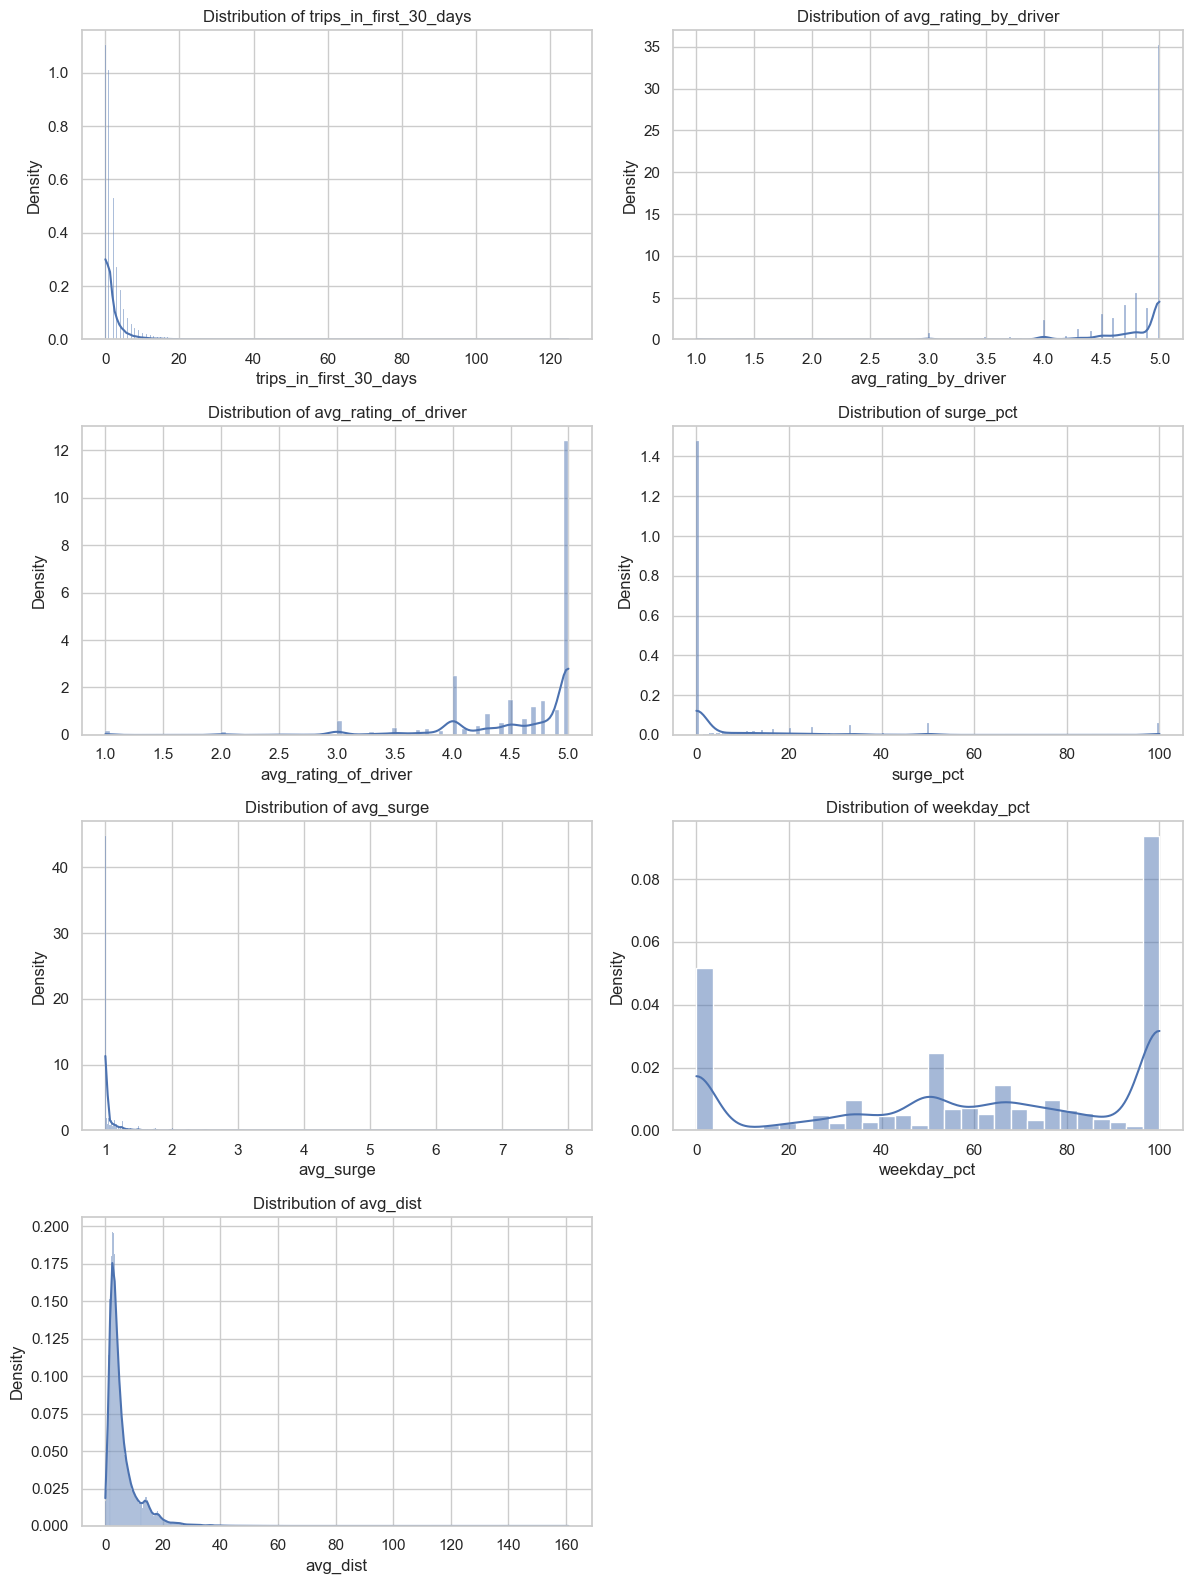

In [28]:
# Visualize feature distributions

# Numeric features grid
n_cols = 2
n_rows = int(np.ceil(len(numeric_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()
for i, feature in enumerate(numeric_features):
    sns.histplot(users[feature].dropna(), kde=True, stat='density', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/numeric_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



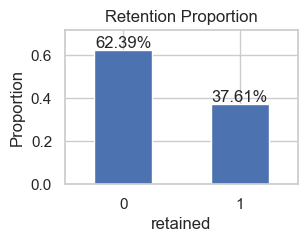

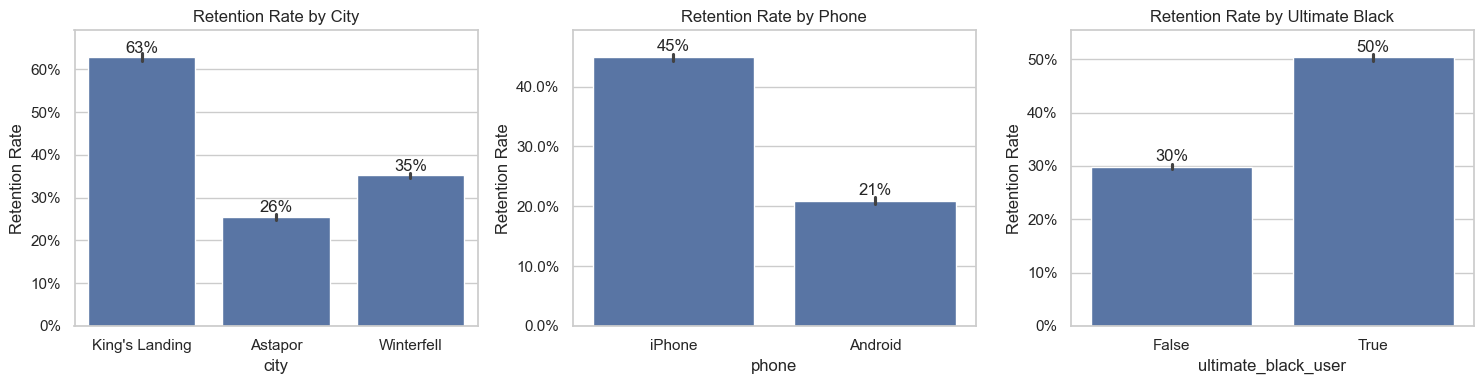

In [36]:
retention_props = users['retained'].value_counts(normalize=True)

plt.figure(figsize=(3, 2))
ax = retention_props.plot(kind='bar', rot=0)
plt.title('Retention Proportion')
plt.ylabel('Proportion')

# Get current max height
y_max = max(p.get_height() for p in ax.patches)

# Add headroom
ax.set_ylim(0, y_max * 1.15)

# Annotate bars
for i, v in enumerate(retention_props):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center')

plt.savefig('../reports/figures/retention_proportion.png', dpi=300, bbox_inches='tight')
plt.show()

# Categorical features by city
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plots = [
    ('city', 'Retention Rate by City'),
    ('phone', 'Retention Rate by Phone'),
    ('ultimate_black_user', 'Retention Rate by Ultimate Black')
]

for ax, (col, title) in zip(axes, plots):
    sns.barplot(x=col, y='retained', data=users, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Retention Rate')

    # Format y-axis as percent
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # Get max bar height
    y_max = max(p.get_height() for p in ax.patches)

    # Add headroom
    ax.set_ylim(0, y_max * 1.1)

    # Add annotations
    
    for p in ax.patches:
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.01,
            f"{p.get_height():.0%}",
            ha='center'
        )

plt.tight_layout()
plt.savefig('../reports/figures/retention_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

The numeric feature plots suggest a user base with many low-activity riders and a smaller group of heavy users. trips_in_first_30_days and avg_dist are both strongly right-skewed, with most users taking few trips and traveling relatively short distances, while a small minority are much more active or travel much farther. Ratings are concentrated near the top of the scale: both avg_rating_by_driver and avg_rating_of_driver cluster heavily around 5, which suggests limited variation in satisfaction measures.

The surge-related variables are also highly skewed. Most users have little or no exposure to surge pricing, but a smaller subset experiences surge much more often, producing long right tails in surge_pct and avg_surge. weekday_pct is spread across the full range, but many users are concentrated near 100%, indicating that a large proportion of riders primarily use the service on weekdays.

The retention-focused categorical plots reveal meaningful differences across groups. Retention is highest among users in King’s Landing and lowest in Astapor, suggesting location may play an important role in engagement. iPhone users have a substantially higher retention rate than Android users, and Ultimate Black members are retained at a much higher rate than non-members. These patterns indicate that city, device type, and premium membership status are all likely to be important predictors of retention.



In [20]:
# Feature selection
drop_cols = ['last_trip_date', 'signup_date', 'retained']
X = users.drop(columns=drop_cols)
y = users['retained']

cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns



All features were included except the target (retained), last_trip_date, which would leak the label definition, and signup_date, which was excluded because nearly all users signed up within the same month and therefore provided little additional signal.

In [21]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((40000, 10), (10000, 10))

In [22]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [23]:
# Full model pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

In [24]:
# Evaluate
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# Save Classification Report and ROC-AUC to CSV
# Convert to dict
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

roc_auc = roc_auc_score(y_test, y_proba)

# Add to DataFrame
report_df.loc['ROC-AUC', 'value'] = roc_auc

# Save
report_df.to_csv('../reports/tables/model_performance.csv')

              precision    recall  f1-score   support

           0       0.78      0.72      0.75      6239
           1       0.59      0.66      0.62      3761

    accuracy                           0.70     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.71      0.70      0.70     10000

ROC-AUC: 0.7538628688432616


### Part 3 Write-up

**Modeling Approach:** 

I started with logistic regression as an interpretable baseline for this binary classification problem and to establish a performance benchmark. Because it assumes linear relationships, it helps assess whether the signal in the data is relatively simple. It also provides clear insight into feature importance, which is valuable before moving to more complex models. From there, I would compare its performance to more flexible approaches, such as gradient boosting, to determine whether capturing nonlinear patterns improves results.

**Performance Summary:** 

The fraction of users retained in the observed cohort was 37.61%, indicating moderate class imbalance.

The logistic regression model achieved:
- Accuracy: 70%
- Precision (retained class): 0.59
- Recall (retained class): 0.66
- F1-score (retained class): 0.62
- ROC-AUC: 0.75

These results indicate that the model performs meaningfully better than the baseline retention rate. In particular, the model identifies 66% of retained users while maintaining reasonable precision, suggesting a balanced tradeoff between capturing retained users and limiting false positives. The ROC-AUC of 0.75 also suggests good discriminative ability for a baseline model.

**Validity Concerns:** 

- Logistic regression assumes linear relationships and may not fully capture more complex interactions between features.
- Performance is evaluated on a single train/test split; cross-validation would provide a more robust estimate of generalization performance. 
- The model does not account for temporal dynamics beyond the available features, limiting its ability to capture user behavior patterns over time. 
- Feature engineering was limited, which may leave predictive signal unused.
- Several numeric features were highly right-skewed (e.g., trips in the first 30 days and average distance). Applying transformations such as a log transform could improve model performance, particularly for logistic regression, which assumes linear relationships.

**Recommendations:**

Ultimate could use this model to identify users at risk of not being retained and target them with interventions such as promotions, incentives, or engagement campaigns. Insights from feature importance could help highlight key drivers of retention, allowing the company to focus on increasing those behaviors. Over time, refining the model with additional features and more flexible models could further improve targeting and retention strategies.